In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import json

from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1. Cargar conjuntos de datos

In [2]:
PROJECT_PATH = '/content/drive/MyDrive/8vo/IA/v3/'
df_train = pd.read_csv(PROJECT_PATH + 'train_set.csv')
df_val = pd.read_csv(PROJECT_PATH + 'val_set.csv')
df_test = pd.read_csv(PROJECT_PATH + 'test_set.csv')

X_train = df_train.drop(columns=['sleep_disorder_risk']).values
y_train = df_train['sleep_disorder_risk'].values

X_val = df_val.drop(columns=['sleep_disorder_risk']).values
y_val = df_val['sleep_disorder_risk'].values

X_test = df_test.drop(columns=['sleep_disorder_risk']).values
y_test = df_test['sleep_disorder_risk'].values

## 2. Construcción del modelo
### 2.1. Declaración del modelo

In [3]:
INPUT_DIM = 57
NUM_CLASSES = 4

inputs = layers.Input(shape=(INPUT_DIM,))

# Capa inicial para ajustar la dimensión
x = layers.Dense(128, activation='relu')(inputs)
x = layers.BatchNormalization()(x)

# Bloque Residual 1
# Guardar la entrada del bloque
residual = x
out = layers.Dense(128, activation='relu')(x)
out = layers.BatchNormalization()(out)
out = layers.Dropout(0.3)(out)
# Sumar la entrada original a la salida (Skip Connection)
x = layers.Add()([residual, out])

# Bloque Residual 2
# Reducir dimensionalidad
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)
residual = x

out = layers.Dense(64, activation='relu')(x)
out = layers.BatchNormalization()(out)
out = layers.Dropout(0.2)(out)
x = layers.Add()([residual, out])

# Capa de salida
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 57)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      7,424 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64)        │          0 │ batch_normalizat… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │        260 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,148 (149.02 KB)

 Trainable params: 37,380 (146.02 KB)

 Non-trainable params: 768 (3.00 KB)

### 2.2. Compilación del modelo

In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
dict_weights = dict(enumerate(weights))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose = 1
)

## 3. Entrenamiento

In [15]:
history = model.fit(
    X_train, y_train,
    class_weight=dict_weights,
    epochs=50,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=early_stop,
    verbose=1
)

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8586 - loss: 0.3630 - val_accuracy: 0.8629 - val_loss: 0.3023
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8628 - loss: 0.3496 - val_accuracy: 0.8665 - val_loss: 0.2962
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8620 - loss: 0.3465 - val_accuracy: 0.8675 - val_loss: 0.2942
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8658 - loss: 0.3401 - val_accuracy: 0.8709 - val_loss: 0.2898
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8662 - loss: 0.3370 - val_accuracy: 0.8693 - val_loss: 0.2936
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8679 - loss: 0.3325 - val_accuracy: 0.8652 - val_loss: 0.2993
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8687 - loss: 0.3314 - val_accuracy: 0.8692 - val_loss: 0.2931
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8699 - loss: 0.3283 - 

## 4. Métricas de entrenamiento

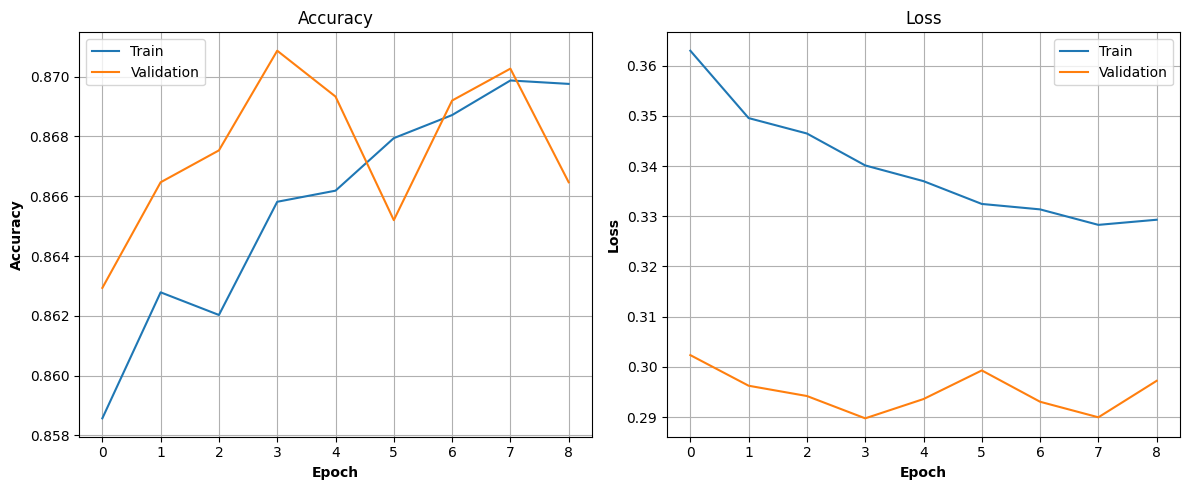

In [16]:
hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
hist_df[['accuracy', 'val_accuracy']].plot(ax=plt.gca())
plt.title('Accuracy')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.legend(['Train', 'Validation'])
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
hist_df[['loss', 'val_loss']].plot(ax=plt.gca())
plt.title('Loss')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend(['Train', 'Validation'])
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Evaluación del modelo (TEST)
### 5.1. Evaluación y predicciones general

In [17]:
class_names = ['Healthy', 'Mild', 'Moderate', 'Severe']

# Evaluación
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

# Predicciones
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8716 - loss: 0.2855
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


### 5.2. Obtener métricas por clase

In [18]:
# Reporte
report = classification_report(y_true, y_pred, target_names=class_names,
                               zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose().loc[class_names]

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
total_samples = np.sum(cm)
accuracy_per_class = []

for i in range(len(class_names)):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp
    tn = total_samples - (tp + fp + fn)
    accuracy_per_class.append((tp + tn) / total_samples)

# Reorganizar
report_df['accuracy'] = accuracy_per_class
metrics = ['precision', 'recall', 'f1-score', 'accuracy']
report_df = report_df[metrics]

### 5.3. Obtener métricas globales

In [21]:
from sklearn.metrics import f1_score, balanced_accuracy_score

f1_gen = f1_score(y_true, y_pred, average='macro')
ba_score = balanced_accuracy_score(y_true, y_pred)

print(f"--- Métricas Globales ---")
print(f"F1-Score General (Macro): {f1_gen*100:.2f}%")
print(f"Balanced Accuracy: {ba_score*100:.2f}%")

--- Métricas Globales ---
F1-Score General (Macro): 80.73%
Balanced Accuracy: 83.67%


### 5.4. Graficar métricas por clase

<Figure size 1200x800 with 0 Axes>

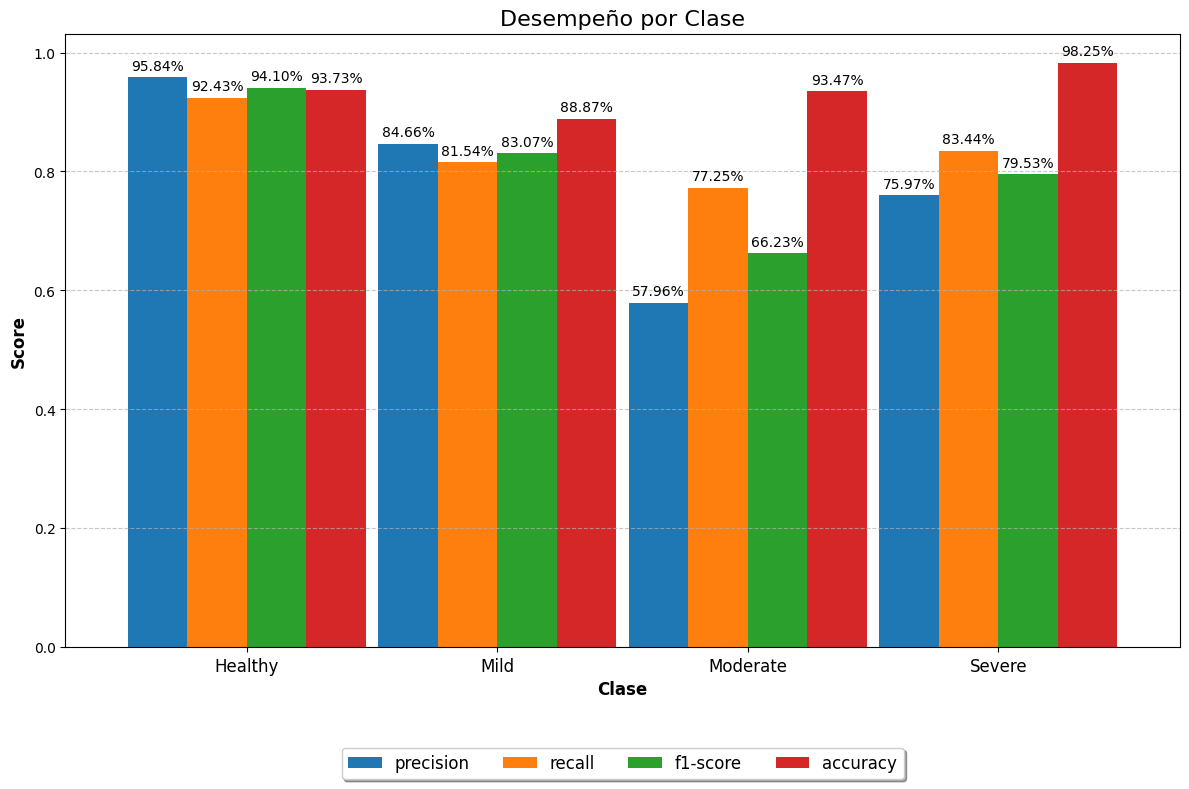

In [22]:
plt.figure(figsize=(12,8))
ax = report_df.plot(kind='bar', figsize=(12, 8), width=0.95)
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)
plt.title("Desempeño por Clase", fontsize=16)
plt.xlabel("Clase", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
           fontsize=12, ncol=4, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### 5.4. Matriz de confusión

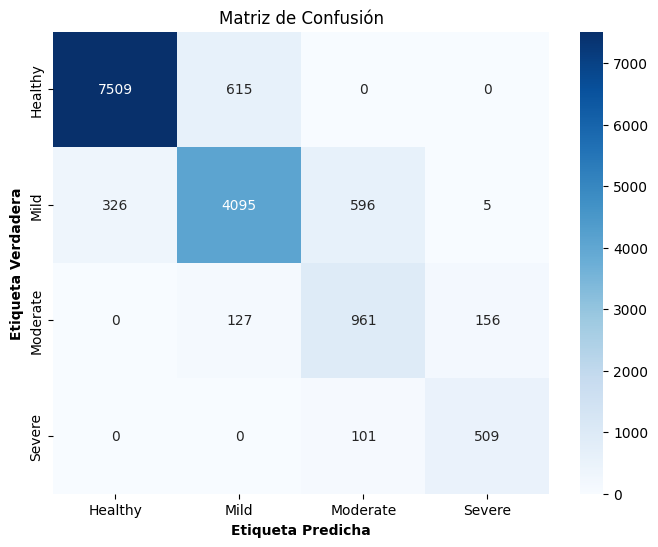

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", xticklabels=class_names,
            yticklabels=class_names)
plt.title("Matriz de Confusión")
plt.ylabel("Etiqueta Verdadera", fontweight='bold')
plt.xlabel("Etiqueta Predicha", fontweight='bold')
plt.show()

## 6. Guardar modelo

In [24]:
model.save(PROJECT_PATH + "tabnet_classifier_model.keras")

with open(PROJECT_PATH + 'tabnet_history.json', 'w') as f:
    json.dump(history.history, f)